In [2]:
%load_ext autoreload
%autoreload 2
import torch
from models.models import EncodeProcessDecode

device = 'cuda:5'
state_dict = torch.load('/data/sam/primal-dual/energy_pdg/multiple_knn/EncodeProcessDecode/GraphPDHGNet/PDHGLayer_L5_H128_inN32_inE32_lam1.0_tau0.35_sig0.35_resid=False_steps=1_featDim=2/0b2mc0ic/final.pt', map_location=device)

/home/jesse/miniconda3/envs/pdhg_net/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
processor_cfg = {
    'model': 'GraphPDHGNet',
    'cfg': {
        'layer_type': 'PDHGLayer',
        'hidden_dim': 128,
        'num_layers': 5,
        'tau': 0.35,
        'sigma': 0.35
    }
}

In [4]:
model = EncodeProcessDecode(processor_cfg,
                            in_node_dim = 2,
                            in_edge_dim = 2,
                            embedding_dim = 32,
                            mlp_hidden_dim=128,
                            residual_stream=False)
model.load_state_dict(state_dict)
model.to(device)

EncodeProcessDecode(
  (node_encoder): MLP(2, 128, 32)
  (edge_encoder): MLP(2, 128, 32)
  (node_decoder): MLP(32, 128, 2)
  (edge_decoder): MLP(32, 128, 2)
  (processor): GraphPDHGNet(
    (layers): ModuleList(
      (0-5): 6 x PDHGLayer()
    )
  )
)

In [5]:
for n, p in model.named_parameters():
    if 'bias' in n:
        print(n, p)

node_encoder.lins.0.bias Parameter containing:
tensor([ 0.3790, -0.6804,  0.5627,  0.6742, -0.6069, -0.1528, -0.1089, -0.0138,
         0.4149, -0.6629, -0.5940, -0.3769,  0.5639, -0.5577,  0.5417,  0.5703,
        -0.2627,  0.2651,  0.3551,  0.0136, -0.2043, -0.5725, -0.0931,  0.2103,
        -0.0738, -0.1639, -0.0645,  0.1244, -0.3445, -0.0469, -0.1875,  0.4387,
         0.5285, -0.5039, -0.1349,  0.1593,  0.0218,  0.4118, -0.0904, -0.0026,
         0.2323,  0.2049, -0.3783,  0.0720,  0.2516, -0.3020, -0.2677,  0.4553,
        -0.6730,  0.0396, -0.4384,  0.5473, -0.1263, -0.3266, -0.1034, -0.5248,
        -0.7019,  0.1438,  0.6116, -0.1865,  0.0237, -0.3520,  0.0654,  0.0905,
         0.3337,  0.3988,  0.0212,  0.6422,  0.5996,  0.5909, -0.6161, -0.1572,
         0.4153,  0.4009,  0.1778, -0.6793,  0.4968, -0.0235, -0.2576,  0.0445,
        -0.6244, -0.4978,  0.4280, -0.2111, -0.1969,  0.0476, -0.0552, -0.6504,
        -0.2598, -0.1283,  0.3875,  0.0462, -0.5746, -0.5956,  0.1203,  0

In [28]:
from sklearn.neighbors import kneighbors_graph
offset = 3.0
n_points_per_cluster = 250
X1 = torch.randn(n_points_per_cluster, 2) - offset
X2 = torch.randn(n_points_per_cluster, 2) + offset

In [33]:
new_offset = torch.tensor([10,10])
X1 = X1 + new_offset
X2 = X2 + new_offset

In [34]:
X = torch.cat([X1, X2], dim=0).to(device)
distances = torch.pdist(X)
knn_graph = kneighbors_graph(X.cpu().numpy(), n_neighbors=8, mode='connectivity', include_self=False)
edge_index = torch.tensor(knn_graph.nonzero(), dtype=torch.long, device=device)
e = (X[edge_index[0]] - X[edge_index[1]]).to(device)
w = torch.norm(e, dim=1).to(device)
out, out_edge = model(X, e, edge_index, w.unsqueeze(1), X)

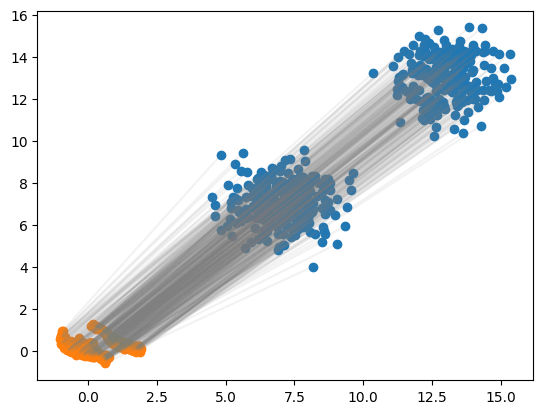

In [36]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

plt.scatter(X[:, 0].cpu(), X[:, 1].cpu())
coords = out.detach().cpu().numpy()
plt.scatter(coords[:, 0], coords[:, 1])
edges = edge_index.cpu().numpy()
lines = [[X.cpu()[i], coords[i]] for i in range(X.shape[0])]
lc = LineCollection(lines, colors='gray', alpha=0.1)
plt.gca().add_collection(lc)
plt.show()

In [17]:
from torch_geometric.utils import get_embeddings

X_encoded = model.node_encoder(X)
e_encoded = model.edge_encoder(e)
distances_encoded = torch.pdist(X_encoded)
X_embeddings = get_embeddings(model.processor, X_encoded, e_encoded, edge_index, w.unsqueeze(1), X_encoded)
distances_embeddings = [torch.pdist(X_embeddings[l]) for l in range(len(X_embeddings))]
distances_out = torch.pdist(out)
all_distances = torch.vstack([distances, distances_encoded] + distances_embeddings + [distances_out])

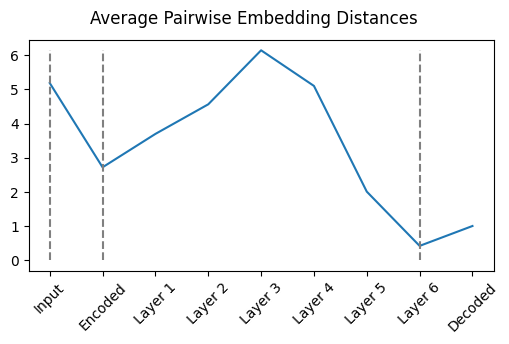

In [18]:
fig, ax = plt.subplots(figsize=(6, 3))
fig.suptitle('Average Pairwise Embedding Distances')
ax.plot(all_distances.mean(dim=1).detach().cpu().numpy())
ax.vlines([0, 1, 1 + len(X_embeddings)], ymin=0, ymax=all_distances.mean(dim=1).max().item(), colors='gray', linestyles='dashed')
ax.set_xticks(range(all_distances.shape[0]))
ax.set_xticklabels(['Input', 'Encoded'] + [f'Layer {i+1}' for i in range(len(X_embeddings))] + ['Decoded'], rotation=45)
plt.show()

In [30]:
c_distances = torch.cdist(X[:250], X[250:]).flatten()
X1_encoded = X_encoded[:250]
X2_encoded = X_encoded[250:]
c_distances_encoded = torch.cdist(X1_encoded, X2_encoded).flatten()
c_distances_embeddings = [torch.cdist(X_embeddings[l][:250], X_embeddings[l][250:]).flatten() for l in range(len(X_embeddings))]
c_distances_out = torch.cdist(out[:250], out[250:]).flatten()
all_c_distances = torch.vstack([c_distances, c_distances_encoded] + c_distances_embeddings + [c_distances_out])

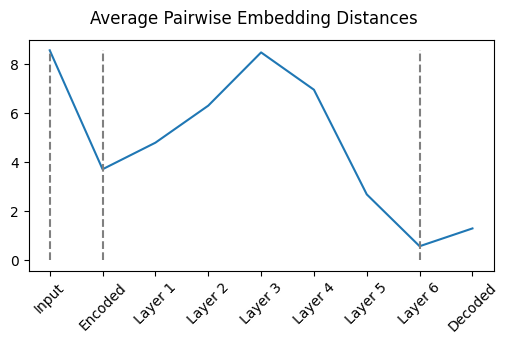

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
fig.suptitle('Average Pairwise Embedding Distances between Clusters')
ax.plot(all_c_distances.mean(dim=1).detach().cpu().numpy())
ax.vlines([0, 1, 1 + len(X_embeddings)], ymin=0, ymax=all_c_distances.mean(dim=1).max().item(), colors='gray', linestyles='dashed')
ax.set_xticks(range(all_c_distances.shape[0]))
ax.set_xticklabels(['Input', 'Encoded'] + [f'Layer {i+1}' for i in range(len(X_embeddings))] + ['Decoded'], rotation=45)
plt.show()